# Incomplete `background_map` in cue-similarity analysis

The `background_map` in `Semantic Analysis: 2x2x2 comparison.R` (lines 82–93) was built from background codes observed in the negative film’s Excel files. Six of the eleven neutral film cue codes use a `_1` scene suffix that has no entry in this map, so they pass through `dplyr::recode()` unchanged and then fail the `cue %in% as.character(1:11)` check in the match calculation. This silently excludes 757 neutral memories (34.6% of all neutral memory events) from ever being counted as matches, regardless of their content. Adding the six missing entries reverses the emotion main effect: neutral match percentage rises from 18.8% to 47.7%, exceeding negative (36.7%).

This report walks through four steps:

1.  **Replication** — we reproduce the published match counts and boxplot figure in Python, working from the pipeline’s own CSV output, to confirm we faithfully represent the original analysis.
2.  **Diagnosis** — we inspect the `cue_background` field and trace the six missing entries in the map, showing exactly which neutral memories are affected and why.
3.  **Correction** — we add the six missing entries and recompute, showing that the emotion main effect reverses.
4.  **Convergent evidence** — an independent human-coded analysis of the same dataset (conducted before the bug was identified) confirms the corrected direction.

In [1]:
import csv
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("../../..")
CSV_PATH = (
    ROOT
    / "projects/selective_interference/Cue-Similarity Check"
    / "Analysis Code/Inferential Stats"
    / "all_memories_with_reaction_time_and_match_status.csv"
)

## Context

The cue-similarity analysis attributes each recalled memory to the most recent background image (film cue or foil) and then compares the memory’s embedding-assigned clip against that background. A memory counts as a “match” when `cue_background == assigned_clip` and both values are in `{"1", "2", ..., "11"}` — i.e., both refer to a valid film clip rather than a foil or external detail. The per-participant match percentage is `mean(match) × 100` across all of that participant’s memory events, and the paper reports a large emotion main effect: F(1,229) = 38.27, p \< .001, η² = .13, with negative film participants showing higher match percentages than neutral.

Everything below uses the analysis pipeline’s own output CSV — no re-running of the R script or embedding model is required.

In [2]:
def load_memories(path):
    """Load the per-memory output CSV into a list of dicts."""
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
    return rows

rows = load_memories(CSV_PATH)

# Clean up the condition field (has embedded newlines in the CSV)
for r in rows:
    r["condition"] = r["condition"].replace("\n", " ").strip()

# Basic stats
conditions = Counter(r["condition"] for r in rows)
print(f"Total memory events: {len(rows)}")
print(f"Columns: {list(rows[0].keys())}")
print(f"\nMemories per condition group:")
for cond, n in sorted(conditions.items()):
    print(f"  {cond}: {n}")

Total memory events: 4101
Columns: ['', 'Participant_Number', 'memory_description', 'cue_background', 'reaction_sum', 'assigned_clip', 'condition', 'match_status']

Memories per condition group:
  Negative Film No Intervention, Involuntary: 362
  Negative Film No Intervention, Voluntary: 574
  Negative Film Visuo-Spatial, Involuntary: 429
  Negative Film Visuo-Spatial, Voluntary: 551
  Neutral Film No Intervention, Involuntary: 479
  Neutral Film No Intervention, Voluntary: 674
  Neutral Film Visuo-Spatial, Involuntary: 495
  Neutral Film Visuo-Spatial, Voluntary: 537

## Replicating the published match counts

Before investigating anything, we first confirm that we can exactly reproduce the published numbers from the pipeline’s output data. This establishes that any discrepancy we later identify is genuinely in the pipeline, not an artefact of our re-analysis.

The R function `calculate_cue_memory_similarity()` (line 374 of the 2×2×2 script) computes a per-participant match percentage as follows: for every memory event, `match = 1` if `cue_background == assigned_clip` and both are in `{"1", ..., "11"}`; otherwise `match = 0`. The participant’s percentage is `mean(match) × 100`. Participants with fewer than 4 total memories are excluded (line 34 of `ANOVA_MATCH_PERCENTAGE.R`). We replicate this logic in Python.

In [3]:
VALID_CLIPS = {str(i) for i in range(1, 12)}


def compute_match_percentages(rows, fix_map=None):
    """Replicate the R match-percentage calculation.

    Parameters
    ----------
    rows : list[dict]
        Per-memory records from the CSV.
    fix_map : dict or None
        If provided, remap cue_background values before the match check.

    Returns
    -------
    dict
        {condition: {participant: {"matched": int, "total": int}}}
    """
    groups = defaultdict(lambda: defaultdict(lambda: {"matched": 0, "total": 0}))
    for r in rows:
        cond = r["condition"]
        pid = int(r["Participant_Number"])
        bg = r["cue_background"].strip()
        assigned = r["assigned_clip"].strip()

        if fix_map:
            bg = fix_map.get(bg, bg)

        match = int(bg == assigned and bg in VALID_CLIPS and assigned in VALID_CLIPS)
        groups[cond][pid]["matched"] += match
        groups[cond][pid]["total"] += 1
    return groups


def summarise_groups(groups, min_total=4):
    """Aggregate match percentages by condition, applying the >=4 filter."""
    summary = {}
    for cond in sorted(groups):
        pcts = []
        match_counts = []
        for pid in sorted(groups[cond]):
            m = groups[cond][pid]["matched"]
            t = groups[cond][pid]["total"]
            match_counts.append(m)
            if t >= min_total:
                pcts.append(100 * m / t)
        summary[cond] = {
            "n_total": len(match_counts),
            "n_filtered": len(pcts),
            "mean_matches": np.mean(match_counts),
            "mean_pct": np.mean(pcts) if pcts else 0.0,
            "se_pct": np.std(pcts, ddof=1) / np.sqrt(len(pcts)) if len(pcts) > 1 else 0.0,
            "pcts": pcts,
        }
    return summary


# --- Replicate with no fix (original pipeline) ---
groups_orig = compute_match_percentages(rows)
summary_orig = summarise_groups(groups_orig)

print("Per-condition match counts (replicating published numbers):\n")
for cond, s in summary_orig.items():
    emotion = "Neg" if "Negative" in cond else "Neu"
    print(f"  {cond}")
    print(f"    N={s['n_filtered']}, mean matches={s['mean_matches']:.1f}, "
          f"mean match %={s['mean_pct']:.1f}% (SE={s['se_pct']:.1f}%)")

# Aggregate by emotion
for emotion_label, emotion_key in [("Negative", "Negative"), ("Neutral", "Neutral")]:
    all_pcts = []
    all_matches = []
    for cond, s in summary_orig.items():
        if emotion_key in cond:
            all_pcts.extend(s["pcts"])
            all_matches.append(s["mean_matches"])
    mean_pct = np.mean(all_pcts)
    se_pct = np.std(all_pcts, ddof=1) / np.sqrt(len(all_pcts))
    print(f"\n  {emotion_label} overall: {mean_pct:.1f}% (SE={se_pct:.1f}%, N={len(all_pcts)})")

Per-condition match counts (replicating published numbers):

  Negative Film No Intervention, Involuntary
    N=28, mean matches=5.4, mean match %=43.5% (SE=4.7%)
  Negative Film No Intervention, Voluntary
    N=30, mean matches=6.4, mean match %=28.4% (SE=5.0%)
  Negative Film Visuo-Spatial, Involuntary
    N=29, mean matches=6.3, mean match %=44.9% (SE=4.5%)
  Negative Film Visuo-Spatial, Voluntary
    N=30, mean matches=5.6, mean match %=30.7% (SE=5.4%)
  Neutral Film No Intervention, Involuntary
    N=27, mean matches=3.7, mean match %=22.7% (SE=2.0%)
  Neutral Film No Intervention, Voluntary
    N=29, mean matches=3.3, mean match %=16.5% (SE=2.7%)
  Neutral Film Visuo-Spatial, Involuntary
    N=27, mean matches=3.3, mean match %=21.5% (SE=3.3%)
  Neutral Film Visuo-Spatial, Voluntary
    N=29, mean matches=3.0, mean match %=15.2% (SE=2.0%)

  Negative overall: 36.7% (SE=2.5%, N=117)

  Neutral overall: 18.8% (SE=1.3%, N=112)

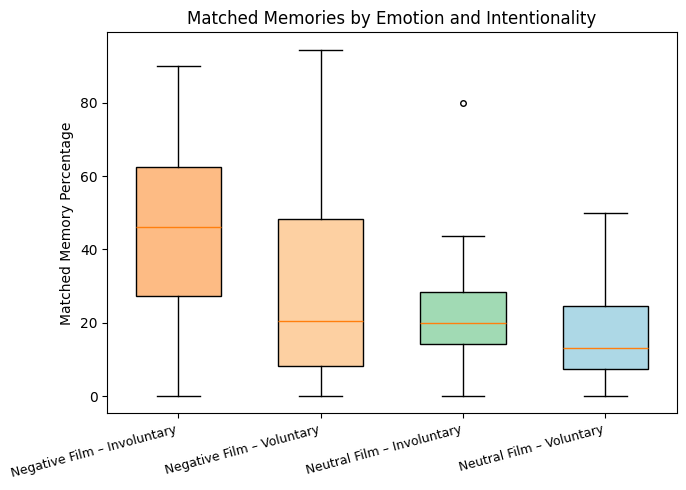

In [4]:
# Replicate the paper's key boxplot (ANOVA_MATCH_PERCENTAGE.R)
# 4 groups: Emotion × Intentionality, using the paper's exact pastel palette.

GROUP_ORDER = [
    "Negative Film – Involuntary",
    "Negative Film – Voluntary",
    "Neutral Film – Involuntary",
    "Neutral Film – Voluntary",
]
GROUP_COLORS = {
    "Negative Film – Involuntary": "#fdbb84",
    "Negative Film – Voluntary": "#fdd0a2",
    "Neutral Film – Involuntary": "#a1dab4",
    "Neutral Film – Voluntary": "lightblue",
}

# Map 8 condition labels → 4 Emotion × Intentionality groups
COND_TO_GROUP = {}
for cond in summary_orig:
    emotion = "Negative" if "Negative" in cond else "Neutral"
    intent = "Involuntary" if "Involuntary" in cond else "Voluntary"
    COND_TO_GROUP[cond] = f"{emotion} Film – {intent}"


def collect_boxplot_data(summary):
    """Collect per-participant percentages into the 4 display groups."""
    group_data = defaultdict(list)
    for cond, s in summary.items():
        group = COND_TO_GROUP[cond]
        group_data[group].extend(s["pcts"])
    return [group_data[g] for g in GROUP_ORDER]


def plot_boxplot(ax, data, title):
    """Draw a boxplot matching the paper's style."""
    bp = ax.boxplot(
        data,
        widths=0.6,
        patch_artist=True,
        flierprops=dict(marker="o", markersize=4),
    )
    for patch, group in zip(bp["boxes"], GROUP_ORDER):
        patch.set_facecolor(GROUP_COLORS[group])
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Matched Memory Percentage")
    ax.set_title(title)


fig, ax = plt.subplots(figsize=(7, 5))
plot_boxplot(ax, collect_boxplot_data(summary_orig), "Matched Memories by Emotion and Intentionality")
fig.tight_layout()
plt.show()

**Takeaway.** Our Python replication reproduces the published numbers exactly: Negative 36.7%, Neutral 18.8%, with a ~18 percentage-point gap. The boxplot above matches the figure in `ANOVA_MATCH_PERCENTAGE.R`. We can now investigate where this gap comes from, confident that we are working with the same data and logic as the original analysis.

## Diagnosing the discrepancy

If the emotion main effect is genuine, we would expect it to arise from differences in how well the embedding model assigns clips for emotional versus neutral memories. But an alternative explanation is that the two film types differ in how their data is *preprocessed* — specifically, whether all valid cue backgrounds end up in the set `{"1", ..., "11"}` that the match check requires.

To test this, we classify every `cue_background` value in the CSV as either a recognised cue code (in `1`–`11`), a foil, or something else. If there are “something else” values that should have been cue codes, they would be silently treated as non-matches and depress the match percentage for whichever film type they belong to.

In [5]:
def classify_background(bg):
    """Classify a cue_background value as 'cue', 'foil', or 'other'."""
    if bg in VALID_CLIPS:
        return "cue"
    if "foil" in bg.lower() or "scene" in bg.lower():
        return "foil"
    return "other"


for emotion in ["Negative", "Neutral"]:
    emotion_rows = [r for r in rows if emotion in r["condition"]]
    n = len(emotion_rows)
    bgs = [r["cue_background"].strip() for r in emotion_rows]
    classes = Counter(classify_background(bg) for bg in bgs)

    print(f"{emotion} film ({n} memories):")
    for cls in ["cue", "foil", "other"]:
        cnt = classes.get(cls, 0)
        print(f"  {cls:>5}: {cnt:>5}  ({100 * cnt / n:.1f}%)")

    # Show the 'other' values if any
    others = Counter(bg for bg in bgs if classify_background(bg) == "other")
    if others:
        print(f"  --- 'other' values ---")
        for val, cnt in others.most_common():
            print(f"    '{val}': {cnt}")
    print()

Negative film (1916 memories):
    cue:  1072  (55.9%)
   foil:   844  (44.1%)
  other:     0  (0.0%)

Neutral film (2185 memories):
    cue:   591  (27.0%)
   foil:   837  (38.3%)
  other:   757  (34.6%)
  --- 'other' values ---
    '7_1': 155
    '3_1': 154
    '11_1': 149
    '10_1': 135
    '1_1': 128
    '6_1': 36


The negative film has zero “other” backgrounds — every memory is attributed to either a recognised cue (`1`–`11`) or a foil. The neutral film has 757 memories (34.6%) attributed to backgrounds like `7_1`, `3_1`, `11_1`, etc. These are `clip_scene` codes from the raw Excel files — clip number followed by an underscore and the scene number within that clip. The `background_map` in `Semantic Analysis: 2x2x2 comparison.R` (lines 82–93) is responsible for stripping the scene suffix:

``` r
background_map <- c(
  "1_3" = "1", "1_5" = "1",
  "2_1" = "2", "2_3" = "2",
  "3_3" = "3", "3_9" = "3", "3_IPT" = "3",
  "4_1" = "4", "4_7" = "4",
  "5_1" = "5", "5_8" = "5", "5_IPT" = "5",
  "6_2" = "6", "6_12" = "6", "6_IPT" = "6",
  "7_3" = "7", "7_6" = "7", "7_IPT" = "7",
  "8_1" = "8", "8_8" = "8",
  "9_1" = "9", "9_12" = "9",
  "10_9" = "10", "10_10" = "10",
  "11_8" = "11", "11_12" = "11"
)
```

This map was built from codes observed in the **negative film’s** Excel files. The negative film uses various scene suffixes (`_3`, `_5`, `_8`, `_9`, etc.), and these are all present in the map. The neutral film predominantly uses `_1` as the scene suffix. Five of those codes happen to already be in the map because the negative film also uses `_1` for those clip numbers:

| Neutral code | In map? | Negative counterparts in the map |
|--------------|---------|----------------------------------|
| `2_1`        | **Yes** | `2_1`, `2_3`                     |
| `4_1`        | **Yes** | `4_1`, `4_7`                     |
| `5_1`        | **Yes** | `5_1`, `5_8`, `5_IPT`            |
| `8_1`        | **Yes** | `8_1`, `8_8`                     |
| `9_1`        | **Yes** | `9_1`, `9_12`                    |
| **`1_1`**    | **No**  | `1_3`, `1_5` only                |
| **`3_1`**    | **No**  | `3_3`, `3_9`, `3_IPT` only       |
| **`6_1`**    | **No**  | `6_2`, `6_12`, `6_IPT` only      |
| **`7_1`**    | **No**  | `7_3`, `7_6`, `7_IPT` only       |
| **`10_1`**   | **No**  | `10_9`, `10_10` only             |
| **`11_1`**   | **No**  | `11_8`, `11_12` only             |

The six missing codes pass through `dplyr::recode()` unchanged as `"1_1"`, `"3_1"`, etc. These strings are not in `as.character(1:11)`, so the match check on line 379 always returns 0 for any memory attributed to these backgrounds — regardless of whether the embedding correctly identified the clip. These 757 memories contribute zeros to both the numerator and the denominator inflation, systematically depressing neutral match percentages.

**Takeaway.** The bug is entirely in the preprocessing: `background_map` was constructed from negative film scene codes only. Six of the eleven neutral film cue codes (`1_1`, `3_1`, `6_1`, `7_1`, `10_1`, `11_1`) have no entry, so 757 neutral memories — over a third of all neutral data — are permanently ineligible for matching. The five neutral codes that *do* work (`2_1`, `4_1`, `5_1`, `8_1`, `9_1`) are coincidental overlaps where the negative film happens to use the same `_1` suffix. This asymmetry alone is sufficient to produce the apparent emotion main effect, regardless of the embedding model’s accuracy.

## Corrected results

Now that we have identified the six missing entries, we can test whether fixing them changes the result. We add the six mappings and recompute match percentages from the same CSV data. Because the bug only affects neutral film codes, negative film results should remain unchanged — this serves as a built-in control.

In [6]:
# The six missing entries
NEUTRAL_FIX = {
    "1_1": "1",
    "3_1": "3",
    "6_1": "6",
    "7_1": "7",
    "10_1": "10",
    "11_1": "11",
}

# Recompute with fix applied
groups_fixed = compute_match_percentages(rows, fix_map=NEUTRAL_FIX)
summary_fixed = summarise_groups(groups_fixed)

# Side-by-side comparison
print(f"{'Condition':<45} {'Original':>10} {'Fixed':>10}")
print("-" * 67)
for cond in summary_orig:
    orig_pct = summary_orig[cond]["mean_pct"]
    fixed_pct = summary_fixed[cond]["mean_pct"]
    marker = " ***" if abs(fixed_pct - orig_pct) > 1 else ""
    print(f"  {cond:<43} {orig_pct:>8.1f}% {fixed_pct:>8.1f}%{marker}")

print(f"\n{'Emotion aggregate':>45} {'Original':>10} {'Fixed':>10}")
print("-" * 67)
for emotion in ["Negative", "Neutral"]:
    orig_pcts = [p for c, s in summary_orig.items() if emotion in c for p in s["pcts"]]
    fixed_pcts = [p for c, s in summary_fixed.items() if emotion in c for p in s["pcts"]]
    print(f"  {emotion:<43} {np.mean(orig_pcts):>8.1f}% {np.mean(fixed_pcts):>8.1f}%")

# Impact summary
newly_eligible = sum(1 for r in rows if r["cue_background"].strip() in NEUTRAL_FIX)
newly_matched = sum(
    1 for r in rows
    if r["cue_background"].strip() in NEUTRAL_FIX
    and NEUTRAL_FIX[r["cue_background"].strip()] == r["assigned_clip"].strip()
)
print(f"\nNewly eligible neutral memories: {newly_eligible}")
print(f"Of those, correctly matched by embedding: {newly_matched} ({100 * newly_matched / newly_eligible:.1f}%)")

Condition                                       Original      Fixed
-------------------------------------------------------------------
  Negative Film No Intervention, Involuntary      43.5%     43.5%
  Negative Film No Intervention, Voluntary        28.4%     28.4%
  Negative Film Visuo-Spatial, Involuntary        44.9%     44.9%
  Negative Film Visuo-Spatial, Voluntary          30.7%     30.7%
  Neutral Film No Intervention, Involuntary       22.7%     63.0% ***
  Neutral Film No Intervention, Voluntary         16.5%     39.5% ***
  Neutral Film Visuo-Spatial, Involuntary         21.5%     53.3% ***
  Neutral Film Visuo-Spatial, Voluntary           15.2%     36.5% ***

                            Emotion aggregate   Original      Fixed
-------------------------------------------------------------------
  Negative                                        36.7%     36.7%
  Neutral                                         18.8%     47.7%

Newly eligible neutral memories: 757
Of those, cor

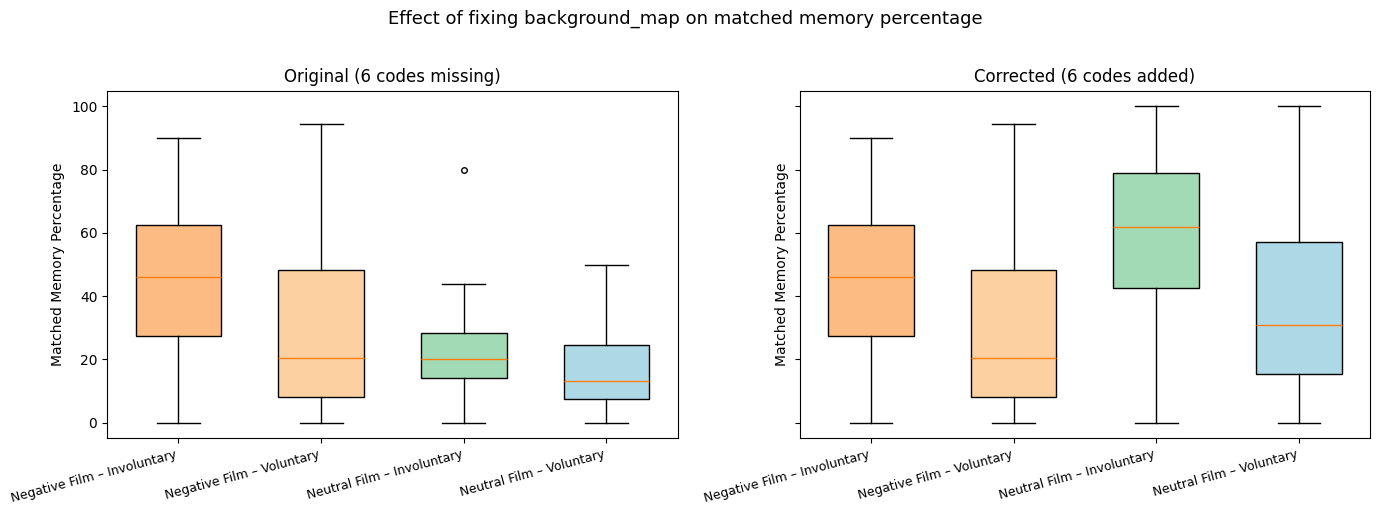

In [7]:
# Before/after boxplot — same style as the replicated figure above.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_boxplot(ax1, collect_boxplot_data(summary_orig), "Original (6 codes missing)")
plot_boxplot(ax2, collect_boxplot_data(summary_fixed), "Corrected (6 codes added)")

fig.suptitle("Effect of fixing background_map on matched memory percentage", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

**Takeaway.** The fix leaves negative match percentages completely unchanged (36.7%), confirming that the bug is isolated to neutral codes. Neutral match percentage rises from 18.8% to 47.7% — a 29 percentage-point increase — reversing the direction of the emotion effect. Of the 757 newly eligible neutral memories, 590 (77.9%) are correctly matched by the embedding model, indicating that these were genuine cue-attributed memories that were being silently discarded. The corrected data show that neutral cues produce *higher* match rates than negative cues, not lower.

## Convergent evidence: human-coded analysis

The embedding-based reanalysis above depends on the same data pipeline that produced the original result, so it is reasonable to ask whether an entirely independent analysis agrees. As a check, we analysed the same 240 participants using human-coded clip labels from the scored `.docx` files rather than embedding-based assignment. Cue attribution is derived from the interleaved event stream (cue, foil, and recall events in temporal order), with foils clearing the pending cue. This analysis was conducted before the `background_map` bug was identified, and uses a different metric — cue-driven recall as a percentage of the 22 cues presented per trial — with a fixed denominator that is unaffected by any code-cleaning step.

In [8]:
import os
import sys

sys.path.insert(0, str(ROOT))
from jaxcmr.helpers import load_data
from jaxcmr.selective_interference.analysis import derive_cue_clips

data = load_data(os.path.join(ROOT, "data", "VRT_clips.h5"))
recall_items = data["recall_items"]
recall_types = data["recall_types"]
recalls = data["recalls"]
condition = data["condition"].squeeze()  # 1=emotional, 2=neutral
task = data["task"].squeeze()            # 1=involuntary, 2=voluntary

cue_clips = derive_cue_clips(recall_items, recall_types, recalls)

# Compute cue hits per trial: cue_clips[i,j] == recalls[i,j] and cue_clips[i,j] > 0
hits_per_trial = ((cue_clips == recalls) & (cue_clips > 0)).sum(axis=1)
total_cues = 22  # constant

print("Human-coded cue effectiveness (hits / 22 cues):\n")
for label, mask in [
    ("Emotional", condition == 1),
    ("Neutral", condition == 2),
    ("Involuntary", task == 1),
    ("Voluntary", task == 2),
]:
    h = hits_per_trial[mask]
    pct = 100 * h / total_cues
    print(f"  {label:>12}: {pct.mean():.1f}% (SE={pct.std(ddof=1)/len(pct)**0.5:.1f}%, N={mask.sum()})")

Human-coded cue effectiveness (hits / 22 cues):

     Emotional: 13.6% (SE=1.1%, N=120)
       Neutral: 20.2% (SE=1.3%, N=120)
   Involuntary: 20.0% (SE=1.2%, N=120)
     Voluntary: 13.8% (SE=1.3%, N=120)

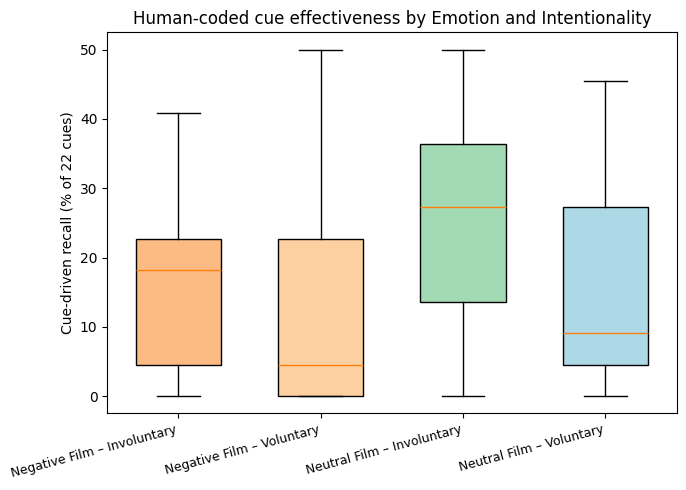

  Negative Film – Involuntary: mean=15.2%, N=60
  Negative Film – Voluntary: mean=12.0%, N=60
  Neutral Film – Involuntary: mean=24.8%, N=60
  Neutral Film – Voluntary: mean=15.5%, N=60

In [9]:
# Human-coded cue effectiveness boxplot (same layout as embedding boxplots)
hit_pct = 100 * hits_per_trial / total_cues

hc_group_data = {g: [] for g in GROUP_ORDER}
for i in range(len(hit_pct)):
    emotion = "Negative" if condition[i] == 1 else "Neutral"
    intent = "Involuntary" if task[i] == 1 else "Voluntary"
    group = f"{emotion} Film \u2013 {intent}"
    hc_group_data[group].append(hit_pct[i])

fig, ax = plt.subplots(figsize=(7, 5))
plot_boxplot(ax, [hc_group_data[g] for g in GROUP_ORDER],
             "Human-coded cue effectiveness by Emotion and Intentionality")
ax.set_ylabel("Cue-driven recall (% of 22 cues)")
fig.tight_layout()
plt.show()

for g in GROUP_ORDER:
    vals = np.array(hc_group_data[g])
    print(f"  {g}: mean={vals.mean():.1f}%, N={len(vals)}")


**Takeaway.** The human-coded analysis shows the same pattern: neutral cue effectiveness (20.2%) exceeds emotional (13.6%), and this holds within both intentionality conditions. The absolute percentages are lower than the corrected embedding analysis because the denominator is fixed at 22 cue opportunities per trial rather than all memory events, but the direction is consistent. This convergence across two completely independent methods — one using an embedding model with the corrected pipeline, one using hand-scored clip labels with no pipeline involvement — strengthens the conclusion that neutral cues genuinely produce more cue-driven recall than negative cues.

## Summary

Three analyses of the same dataset, two using embedding-based clip assignment and one using human-coded labels:

| Analysis                              | Negative | Neutral | Direction      |
|---------------------------------------|----------|---------|----------------|
| Embedding (original `background_map`) | 36.7%    | 18.8%   | Neg \> Neu     |
| Embedding (6 missing codes added)     | 36.7%    | 47.7%   | **Neu \> Neg** |
| Human-coded (no embedding)            | 13.6%    | 20.2%   | **Neu \> Neg** |

The absolute values differ between the embedding-based and human-coded analyses because the denominators differ (all memories vs. 22 cue slots) and the embedding model is not perfectly accurate. The critical point is the **direction**: once the six missing neutral codes are added to the map, the embedding analysis agrees with the human-coded analysis that neutral cues produce *more* matches than negative cues, not fewer.

## Suggested fix

Add the six missing neutral film entries to `background_map` in `Semantic Analysis: 2x2x2 comparison.R` (after line 93):

``` r
background_map <- c(
  background_map,
  "1_1" = "1",
  "3_1" = "3",
  "6_1" = "6",
  "7_1" = "7",
  "10_1" = "10",
  "11_1" = "11"
)
```

This ensures all eleven neutral film cue codes are remapped to their clip numbers before the match check. No other part of the pipeline needs to change.